<a href="https://colab.research.google.com/github/tomasbelak24/deeplearning-vision/blob/main/hw1/dropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Dropout and Augmentation (4pt)

Test the dropout so that it is first only in the fully connected layer (p = 0.5) and then also after the convolutional layers (p = 0.2). And one more option. Remember to use Dropout2d instead of Dropout1d when using in convolution layers.

Test augmentation for 3 different settings. You can be creative, but it should at least make sense. Documentation can be found [here](https://pytorch.org/vision/stable/transforms.html). Be careful to do it right.

Test both things for two cases in one you use a regular split on train/val and in the other you leave only the first 1000 examples in the training set. Be aware that the number of training steps is smaller for the second case, so use proportionately more epochs.

In [ ]:
!mkdir -p baseline
# I might make the repo private in the future so the files from /baseline directory from the zip file might have to be used
!wget -O baseline/baseline_results.json https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json


--2025-11-19 16:22:53--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/models/baseline_model.pth
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 381333 (372K) [application/octet-stream]
Saving to: ‘baseline/baseline_model.pth’

baseline/baseline_m 100%[===================>] 372.40K  --.-KB/s    in 0.02s   

2025-11-19 16:22:53 (16.8 MB/s) - ‘baseline/baseline_model.pth’ saved [381333/381333]

--2025-11-19 16:22:53--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443.

In [ ]:
import json

with open('baseline/baseline_results.json', 'r') as f:
    baseline_results = json.load(f)

baseline_train_losses = baseline_results['train_losses']
baseline_val_losses = baseline_results['val_losses']
baseline_val_accs = baseline_results['val_accuracies']

print("Baseline results loaded successfully.")

Baseline results loaded successfully.


In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms

import numpy as np
from matplotlib import pyplot as plt

100%|██████████| 170M/170M [00:06<00:00, 26.3MB/s]


torch.Size([1, 3, 32, 32])


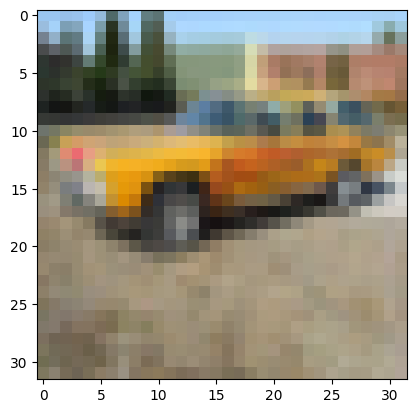

tensor([1])
car
torch.Size([1, 3, 32, 32])


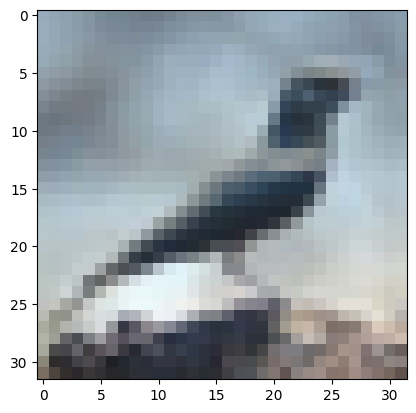

tensor([2])
bird
torch.Size([1, 3, 32, 32])


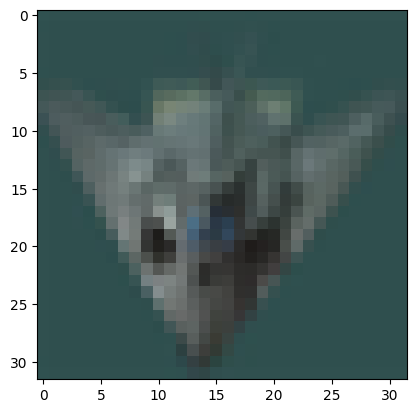

tensor([0])
plane
torch.Size([1, 3, 32, 32])


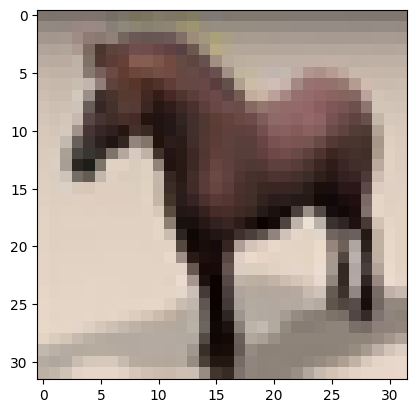

tensor([7])
horse
torch.Size([1, 3, 32, 32])


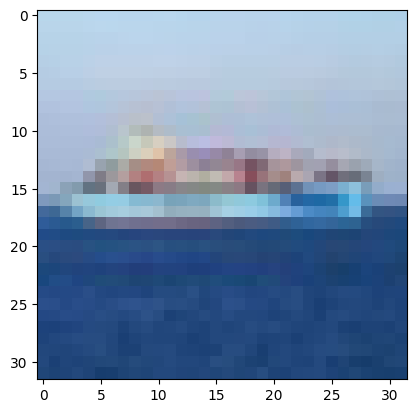

tensor([8])
ship
torch.Size([1, 3, 32, 32])


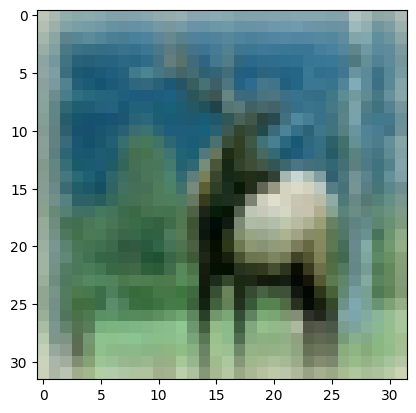

tensor([4])
deer
torch.Size([1, 3, 32, 32])


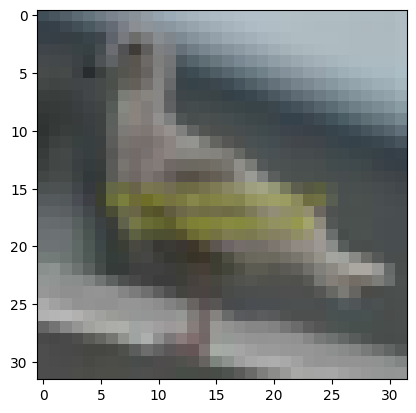

tensor([2])
bird
torch.Size([1, 3, 32, 32])


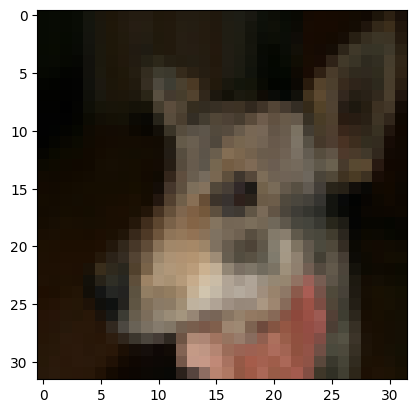

tensor([5])
dog
torch.Size([1, 3, 32, 32])


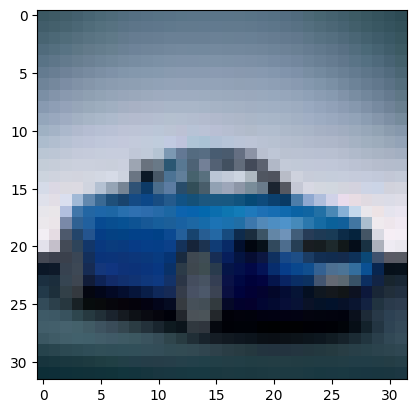

tensor([1])
car
torch.Size([1, 3, 32, 32])


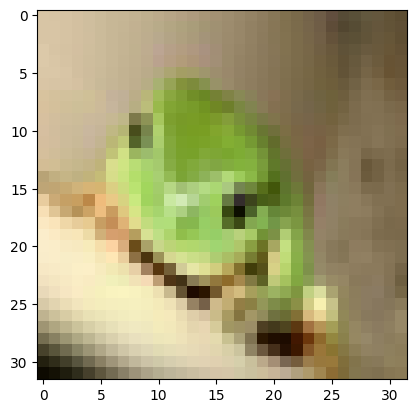

tensor([6])
frog
torch.Size([1, 3, 32, 32])


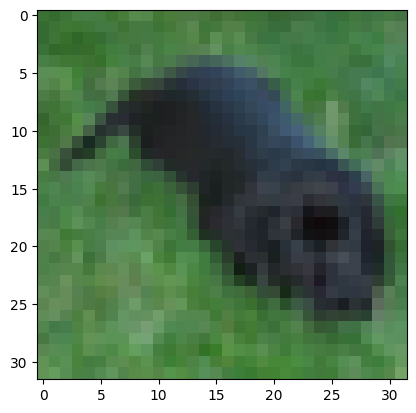

tensor([5])
dog


In [ ]:
# @title Loading CIFAR10 dataset

#reused code from the 5th lab

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

transform = transforms.ToTensor()

dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# for reproducibility
trainset, valset = torch.utils.data.random_split(dataset, [45000, 5000], generator=torch.Generator().manual_seed(42))

previewloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

for i, sample in enumerate(previewloader):
  if i > 10:
    break
  x, y = sample
  print(x.shape)
  img = np.moveaxis(x.numpy()[0], 0, -1)
  plt.imshow(img)
  plt.show()
  print(y)
  print(classes[y.item()])

Model architectures

In [ ]:
from torch.nn import ReLU, Softmax, Sequential, Linear, Conv2d, MaxPool2d, Flatten, AdaptiveAvgPool2d, Dropout, Dropout2d

def build_model_task4_fc_only(num_classes=10, p_fc=0.5):
    model = Sequential(
          Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
          MaxPool2d(2),
          Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
          MaxPool2d(2),
          Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
          MaxPool2d(2),

          AdaptiveAvgPool2d(1),
          Flatten(),
          Dropout(p=p_fc),
          Linear(128, num_classes)
    )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference


def build_model_task4_both(num_classes=10, p_conv=0.2, p_fc=0.5):
    model = Sequential(
          Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
          Dropout2d(p=p_conv), MaxPool2d(2),
          Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
          Dropout2d(p=p_conv), MaxPool2d(2),
          Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
          Dropout2d(p=p_conv), MaxPool2d(2),

          AdaptiveAvgPool2d(1),
          Flatten(),
          Dropout(p=p_fc),
          Linear(128, num_classes)
      )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference


def build_model_task4_conv_only(num_classes=10, p_conv=0.2):
    model = Sequential(
        Conv2d(3, 32, 3, padding=1, bias=True), ReLU(),
        Dropout2d(p=p_conv),
        MaxPool2d(2),

        Conv2d(32, 64, 3, padding=1, bias=True), ReLU(),
        Dropout2d(p=p_conv),
        MaxPool2d(2),

        Conv2d(64, 128, 3, padding=1, bias=True), ReLU(),
        Dropout2d(p=p_conv),
        MaxPool2d(2),

        AdaptiveAvgPool2d(1),
        Flatten(),
        Linear(128, num_classes)
      )

    model_inference = Sequential(model, Softmax(dim=1))
    return model, model_inference


model, model_inference = build_model_task4_conv_only()

out = model_inference(torch.from_numpy(np.zeros([1, 3, 32, 32], dtype=np.float32)))
print(out.size())
print(out)
print(classes[out.argmax().item()])

torch.Size([1, 10])
tensor([[0.1006, 0.1000, 0.1056, 0.0915, 0.0944, 0.0994, 0.1047, 0.1012, 0.1026,
         0.1000]], grad_fn=<SoftmaxBackward0>)
bird


In [ ]:
def one_epoch(model, loss, optimizer, dataloader_train, dataloader_val, verbose=True):
  train_losses = []
  val_losses = []

  model.train()
  for i, batch in enumerate(dataloader_train):
    x, y = batch[0].to(device), batch[1].to(device)
    optimizer.zero_grad()

    out = model(x)
    loss = ce_loss(out, y)
    loss.backward()
    train_losses.append(loss.item())
    optimizer.step()
    if i % 100 == 0 and verbose:
      print("Training loss at step {}: {}".format(i, loss.item()))

  model.eval()
  with torch.no_grad():
    correct = 0
    total = 0
    for i, batch in enumerate(dataloader_val):
      x, y = batch[0].to(device), batch[1].to(device)

      out = model(x)
      loss = ce_loss(out, y)
      acc = torch.sum(torch.argmax(out, dim=-1) == y)
      correct += acc.item()
      total += len(batch[1])
      val_losses.append(loss.item())

  val_acc = correct / total

  return np.mean(train_losses), np.mean(val_losses), val_acc

### Training on 45000 samples

Using device:  cuda:0
Trying dropout setting: fc_dropout(p=0.5)
Val loss at epoch 0: 1.5563594444542175
Val acc at epoch 0: 0.4384
Val loss at epoch 1: 1.3911749435837861
Val acc at epoch 1: 0.5074
Val loss at epoch 2: 1.3143359673251012
Val acc at epoch 2: 0.5298
Val loss at epoch 3: 1.2208869685033323
Val acc at epoch 3: 0.5712
Val loss at epoch 4: 1.2384726215320028
Val acc at epoch 4: 0.5646
Val loss at epoch 5: 1.122556350793049
Val acc at epoch 5: 0.5878
Val loss at epoch 6: 1.0706289961079882
Val acc at epoch 6: 0.6144
Val loss at epoch 7: 1.099168429329137
Val acc at epoch 7: 0.6224
Val loss at epoch 8: 1.0218934033327043
Val acc at epoch 8: 0.6374
Val loss at epoch 9: 0.9735187227558938
Val acc at epoch 9: 0.6594
Val loss at epoch 10: 0.9579468802282005
Val acc at epoch 10: 0.6556
Val loss at epoch 11: 0.939855788164078
Val acc at epoch 11: 0.6744
Val loss at epoch 12: 0.9186563799335699
Val acc at epoch 12: 0.6808
Val loss at epoch 13: 0.8773942536609188
Val acc at epoch 13: 

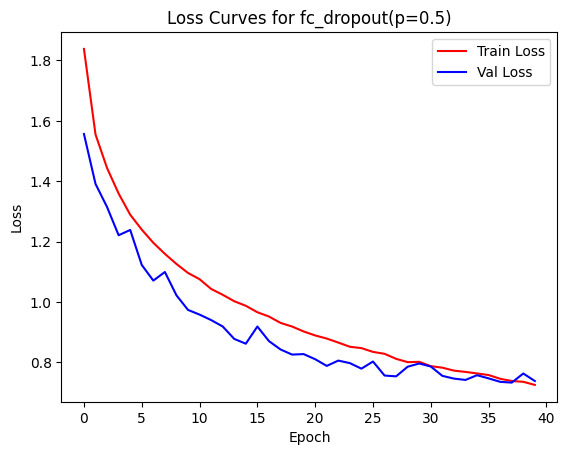

Trying dropout setting: fc_dropout(p=0.5) & conv_dropout(p=0.2)
Val loss at epoch 0: 1.6671328332014144
Val acc at epoch 0: 0.416
Val loss at epoch 1: 1.518252321868945
Val acc at epoch 1: 0.4596
Val loss at epoch 2: 1.4191403335826411
Val acc at epoch 2: 0.494
Val loss at epoch 3: 1.3694891185517524
Val acc at epoch 3: 0.5244
Val loss at epoch 4: 1.2855737664896971
Val acc at epoch 4: 0.5374
Val loss at epoch 5: 1.2464245489448498
Val acc at epoch 5: 0.5588
Val loss at epoch 6: 1.2282451227971702
Val acc at epoch 6: 0.5798
Val loss at epoch 7: 1.2011289793974276
Val acc at epoch 7: 0.5782
Val loss at epoch 8: 1.1834688980108614
Val acc at epoch 8: 0.592
Val loss at epoch 9: 1.135537822914731
Val acc at epoch 9: 0.6092
Val loss at epoch 10: 1.1141273371732918
Val acc at epoch 10: 0.6072
Val loss at epoch 11: 1.093313673119636
Val acc at epoch 11: 0.6194
Val loss at epoch 12: 1.0800652564710873
Val acc at epoch 12: 0.636
Val loss at epoch 13: 1.064148630685867
Val acc at epoch 13: 0.634

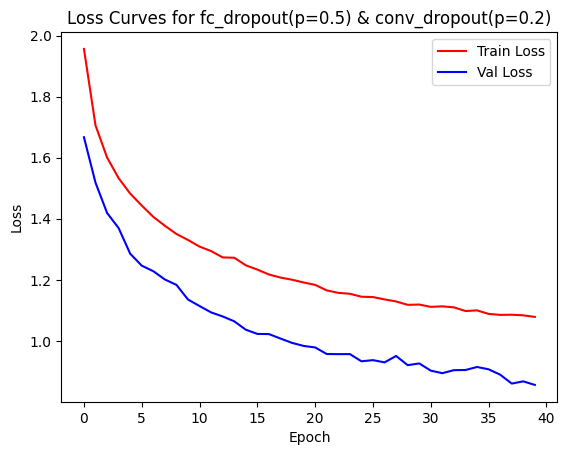

Trying dropout setting: conv_dropout(p=0.2)
Val loss at epoch 0: 1.6412533772219517
Val acc at epoch 0: 0.4072
Val loss at epoch 1: 1.4486912025767527
Val acc at epoch 1: 0.482
Val loss at epoch 2: 1.3459456259277975
Val acc at epoch 2: 0.5202
Val loss at epoch 3: 1.2851780744115258
Val acc at epoch 3: 0.5402
Val loss at epoch 4: 1.1988048280120656
Val acc at epoch 4: 0.5796
Val loss at epoch 5: 1.1248515096439677
Val acc at epoch 5: 0.6114
Val loss at epoch 6: 1.1037525344806112
Val acc at epoch 6: 0.6148
Val loss at epoch 7: 1.0502439475363228
Val acc at epoch 7: 0.6308
Val loss at epoch 8: 1.0383138960334146
Val acc at epoch 8: 0.645
Val loss at epoch 9: 1.0247042422082013
Val acc at epoch 9: 0.6404
Val loss at epoch 10: 0.9658319581845763
Val acc at epoch 10: 0.6622
Val loss at epoch 11: 0.9435663880056636
Val acc at epoch 11: 0.6728
Val loss at epoch 12: 0.9246719813650581
Val acc at epoch 12: 0.6778
Val loss at epoch 13: 0.8843254720329479
Val acc at epoch 13: 0.7018
Val loss at 

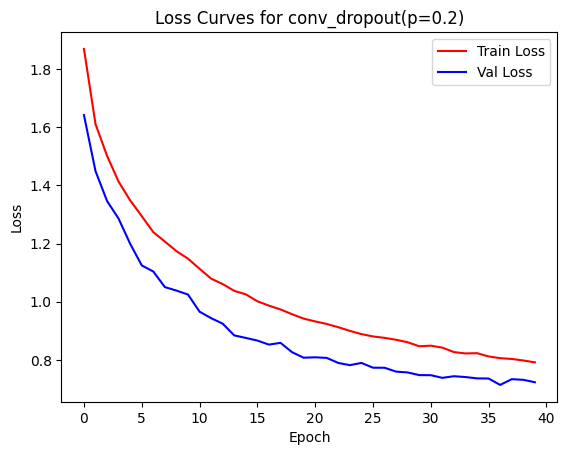

Trying dropout setting: fc_dropout(p=0.5) & conv_dropout(p=0.1)
Val loss at epoch 0: 1.5845960363460954
Val acc at epoch 0: 0.4268
Val loss at epoch 1: 1.4644317809183887
Val acc at epoch 1: 0.479
Val loss at epoch 2: 1.3288202589484537
Val acc at epoch 2: 0.5206
Val loss at epoch 3: 1.2735750872618075
Val acc at epoch 3: 0.5608
Val loss at epoch 4: 1.191442608833313
Val acc at epoch 4: 0.5904
Val loss at epoch 5: 1.1445040585129125
Val acc at epoch 5: 0.5982
Val loss at epoch 6: 1.1066845313758606
Val acc at epoch 6: 0.6158
Val loss at epoch 7: 1.0852158699825312
Val acc at epoch 7: 0.6306
Val loss at epoch 8: 1.0759132572799732
Val acc at epoch 8: 0.6306
Val loss at epoch 9: 1.0218253598851004
Val acc at epoch 9: 0.6508
Val loss at epoch 10: 1.00260128906578
Val acc at epoch 10: 0.6516
Val loss at epoch 11: 0.9691159007655588
Val acc at epoch 11: 0.6694
Val loss at epoch 12: 0.9559714710636503
Val acc at epoch 12: 0.6746
Val loss at epoch 13: 0.9506185111726165
Val acc at epoch 13: 0

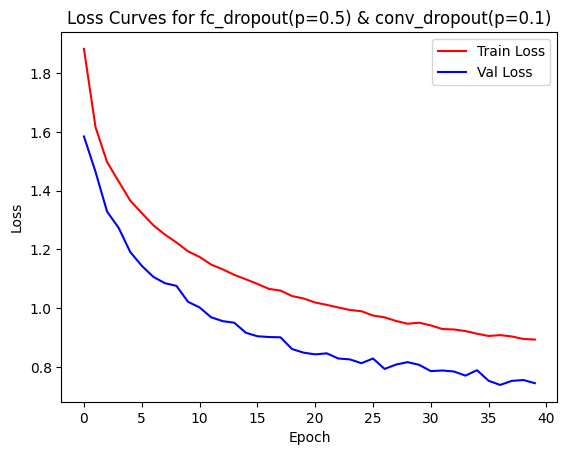

In [ ]:
configs = [ {'name': 'fc_dropout(p=0.5)','build_model': lambda: build_model_task4_fc_only(10, 0.5)},
            {'name': 'fc_dropout(p=0.5) & conv_dropout(p=0.2)', 'build_model': lambda: build_model_task4_both(10, p_fc=0.5, p_conv=0.2)},
            {'name': 'conv_dropout(p=0.2)', 'build_model': lambda: build_model_task4_conv_only(10, p_conv=0.2)},
            {'name': 'fc_dropout(p=0.5) & conv_dropout(p=0.1)', 'build_model': lambda: build_model_task4_both(10, p_fc=0.5, p_conv=0.1)}
          ]

losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

batch_size = 32

dataloader_train = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying dropout setting: {config['name']}")

    model_builder = config['build_model']

    model, model_inference = model_builder()
    model.to(device)
    model_inference.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(40):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        print(f"Val loss at epoch {e}: {val_loss}")
        print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
import json

results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

output_filename = 'dropout_results.json'

with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to dropout_results.json


### baseline comparison

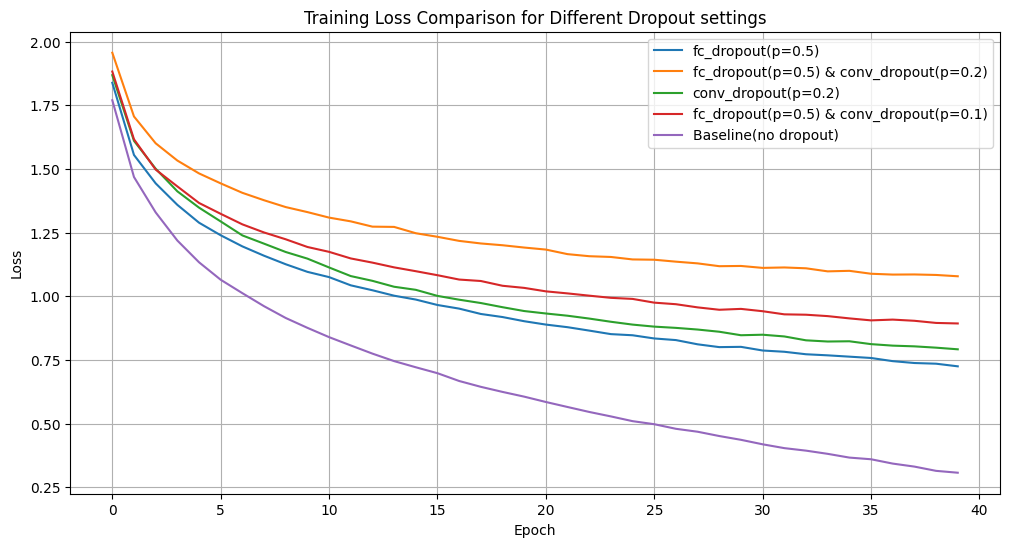

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][0][0], label=optimizer_name['name'])

plt.plot(baseline_train_losses, label='Baseline(no dropout)')

plt.title('Training Loss Comparison for Different Dropout settings')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

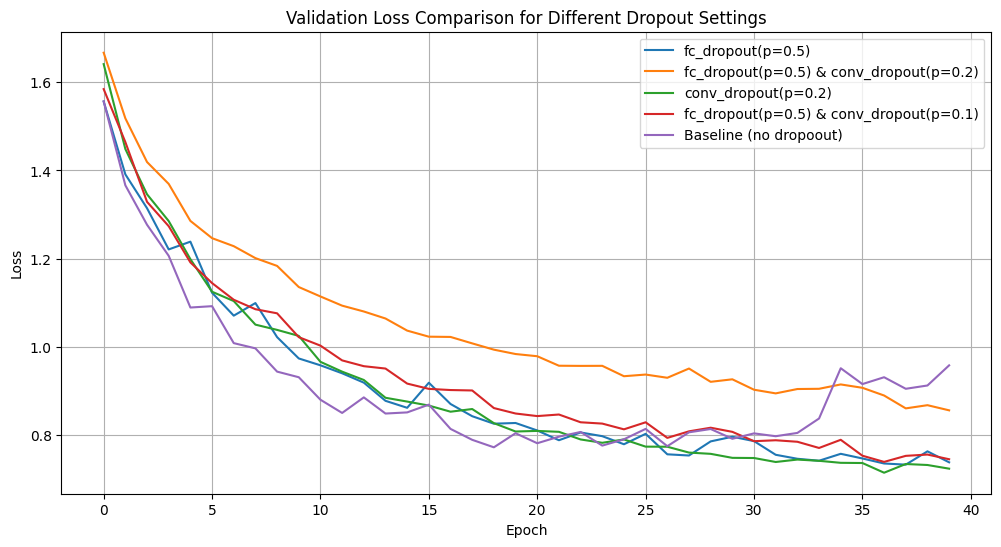

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][1][0], label=optimizer_name['name'])

plt.plot(baseline_val_losses, label='Baseline (no dropoout)')

plt.title('Validation Loss Comparison for Different Dropout Settings')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

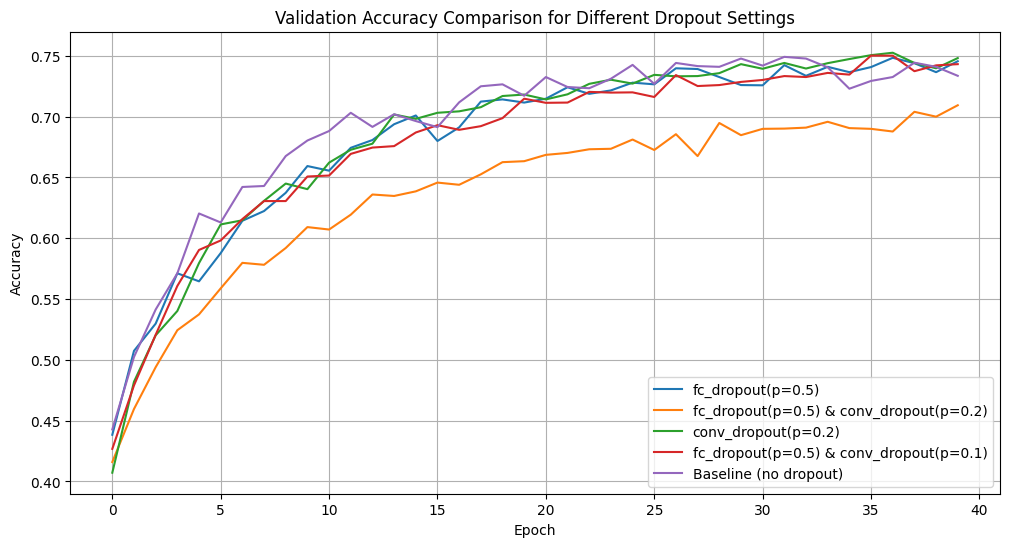

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(accuracies[optimizer_name['name']][0], label=optimizer_name['name'])

plt.plot(baseline_val_accs, label='Baseline (no dropout)')

plt.title('Validation Accuracy Comparison for Different Dropout Settings')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

summary_data = {}

# Get baseline results
summary_data['Baseline (no dropout)'] = {
    'Final Train Loss': baseline_train_losses[-1],
    'Final Val Loss': baseline_val_losses[-1],
    'Final Val Accuracy': baseline_val_accs[-1]
}

# Get results for each optimizer
for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
Baseline (no dropout),0.307193,0.957867,0.7336
fc_dropout(p=0.5),0.724962,0.737868,0.7456
fc_dropout(p=0.5) & conv_dropout(p=0.2),1.078584,0.855808,0.7094
conv_dropout(p=0.2),0.791810,0.723471,0.7482
fc_dropout(p=0.5) & conv_dropout(p=0.1),0.893291,0.744858,0.7432


### Dropout on 1000 sample train set

Using device:  cuda:0
Trying dropout setting: fc_dropout(p=0.5)
Val loss at epoch 0: 2.281238749350954
Val acc at epoch 0: 0.12148979591836735
Val loss at epoch 10: 1.8778528788226703
Val acc at epoch 10: 0.2829591836734694
Val loss at epoch 20: 1.737122406380606
Val acc at epoch 20: 0.34546938775510205
Val loss at epoch 30: 1.641115416356851
Val acc at epoch 30: 0.3833061224489796
Val loss at epoch 40: 1.6000799100174916
Val acc at epoch 40: 0.4016530612244898
Val loss at epoch 50: 1.5742193152325583
Val acc at epoch 50: 0.41477551020408165
Val loss at epoch 60: 1.561499652990162
Val acc at epoch 60: 0.427
Val loss at epoch 70: 1.5601346781063952
Val acc at epoch 70: 0.4321020408163265
Val loss at epoch 80: 1.622939370669833
Val acc at epoch 80: 0.43073469387755103
Val loss at epoch 90: 1.5664697991338785
Val acc at epoch 90: 0.4412857142857143
Val loss at epoch 100: 1.5825927305003682
Val acc at epoch 100: 0.4520612244897959
Val loss at epoch 110: 1.5943539318076625
Val acc at epoch 

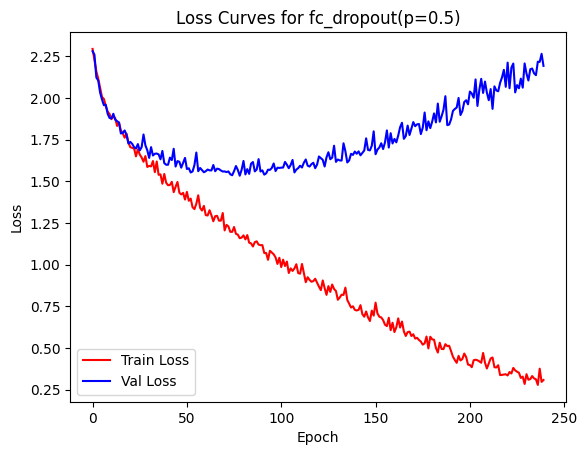

Trying dropout setting: fc_dropout(p=0.5) & conv_dropout(p=0.2)
Val loss at epoch 0: 2.2830824038067314
Val acc at epoch 0: 0.11061224489795918
Val loss at epoch 10: 2.0138042092945807
Val acc at epoch 10: 0.2266734693877551
Val loss at epoch 20: 1.8448396448055695
Val acc at epoch 20: 0.3210612244897959
Val loss at epoch 30: 1.756887995465306
Val acc at epoch 30: 0.3506530612244898
Val loss at epoch 40: 1.6617256595945233
Val acc at epoch 40: 0.39387755102040817
Val loss at epoch 50: 1.6162109827870799
Val acc at epoch 50: 0.4079591836734694
Val loss at epoch 60: 1.5837169469336616
Val acc at epoch 60: 0.4237142857142857
Val loss at epoch 70: 1.5567642411426215
Val acc at epoch 70: 0.4296122448979592
Val loss at epoch 80: 1.5205803597564798
Val acc at epoch 80: 0.4406326530612245
Val loss at epoch 90: 1.499389989102167
Val acc at epoch 90: 0.4500612244897959
Val loss at epoch 100: 1.498378313786056
Val acc at epoch 100: 0.45422448979591834
Val loss at epoch 110: 1.4716700282015938
Val

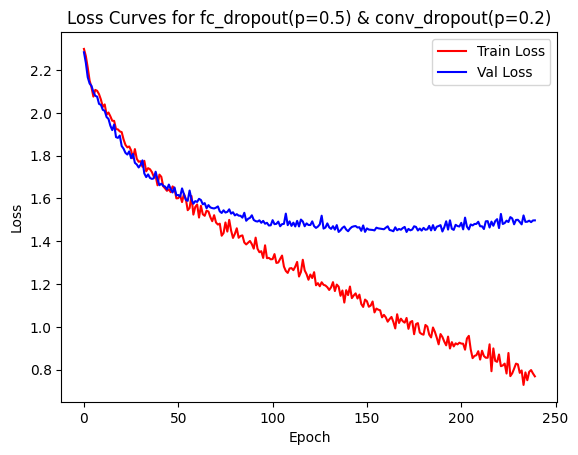

Trying dropout setting: conv_dropout(p=0.2)
Val loss at epoch 0: 2.2952361961257677
Val acc at epoch 0: 0.10983673469387756
Val loss at epoch 10: 1.9386973340579798
Val acc at epoch 10: 0.29606122448979594
Val loss at epoch 20: 1.800699355630277
Val acc at epoch 20: 0.3350204081632653
Val loss at epoch 30: 1.683213687596682
Val acc at epoch 30: 0.3884489795918367
Val loss at epoch 40: 1.6357344209214104
Val acc at epoch 40: 0.39524489795918366
Val loss at epoch 50: 1.5808259800426643
Val acc at epoch 50: 0.4185510204081633
Val loss at epoch 60: 1.5810261721243746
Val acc at epoch 60: 0.41744897959183674
Val loss at epoch 70: 1.5405934232022058
Val acc at epoch 70: 0.43514285714285716
Val loss at epoch 80: 1.5646200707624849
Val acc at epoch 80: 0.4336938775510204
Val loss at epoch 90: 1.5468951802963375
Val acc at epoch 90: 0.43773469387755104
Val loss at epoch 100: 1.5083876017957691
Val acc at epoch 100: 0.4582857142857143
Val loss at epoch 110: 1.537591027450935
Val acc at epoch 110

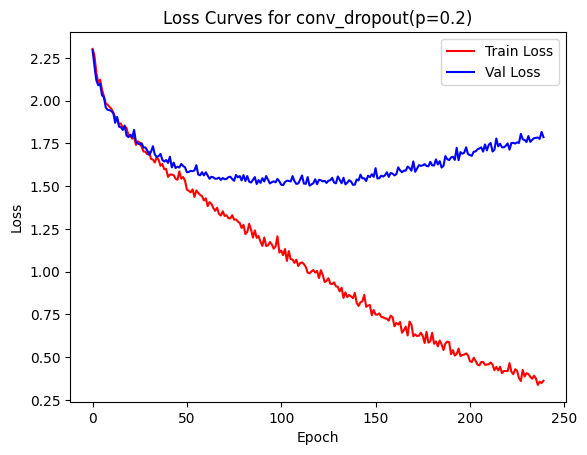

Trying dropout setting: fc_dropout(p=0.5) & conv_dropout(p=0.1)
Val loss at epoch 0: 2.2837228326822387
Val acc at epoch 0: 0.11438775510204081
Val loss at epoch 10: 2.0469619203796587
Val acc at epoch 10: 0.23387755102040816
Val loss at epoch 20: 1.8051064370817678
Val acc at epoch 20: 0.31885714285714284
Val loss at epoch 30: 1.6618780797206392
Val acc at epoch 30: 0.3915918367346939
Val loss at epoch 40: 1.6038384169106694
Val acc at epoch 40: 0.41391836734693876
Val loss at epoch 50: 1.5811078869798476
Val acc at epoch 50: 0.4175510204081633
Val loss at epoch 60: 1.5274581042344515
Val acc at epoch 60: 0.43548979591836734
Val loss at epoch 70: 1.525495504274692
Val acc at epoch 70: 0.4445918367346939
Val loss at epoch 80: 1.5180898900909772
Val acc at epoch 80: 0.4433265306122449
Val loss at epoch 90: 1.4869719480332133
Val acc at epoch 90: 0.46238775510204083
Val loss at epoch 100: 1.4717554838710292
Val acc at epoch 100: 0.46746938775510205
Val loss at epoch 110: 1.48997171207601

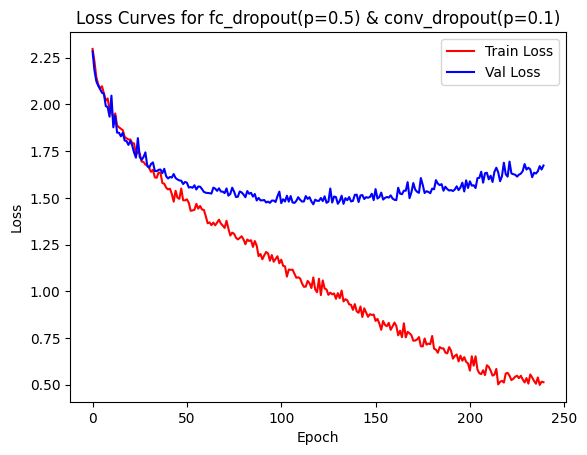

In [ ]:
trainset, valset = torch.utils.data.random_split(dataset, [1000, 49000], generator=torch.Generator().manual_seed(42))

configs = [ {'name': 'fc_dropout(p=0.5)','build_model': lambda: build_model_task4_fc_only(10, 0.5)},
            {'name': 'fc_dropout(p=0.5) & conv_dropout(p=0.2)', 'build_model': lambda: build_model_task4_both(10, p_fc=0.5, p_conv=0.2)},
            {'name': 'conv_dropout(p=0.2)', 'build_model': lambda: build_model_task4_conv_only(10, p_conv=0.2)},
            {'name': 'fc_dropout(p=0.5) & conv_dropout(p=0.1)', 'build_model': lambda: build_model_task4_both(10, p_fc=0.5, p_conv=0.1)}
          ]

losses = {config['name']: ([], []) for config in configs}
accuracies = {config['name']: [] for config in configs}

batch_size = 32

dataloader_train = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
dataloader_val = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Using device: ", device)

ce_loss = torch.nn.CrossEntropyLoss().to(device)

for config in configs:
    print(f"Trying dropout setting: {config['name']}")

    model_builder = config['build_model']

    model, model_inference = model_builder()
    model.to(device)
    model_inference.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    epoch_train_losses = []
    epoch_val_losses = []
    epoch_val_accs = []

    for e in range(240):
        train_loss, val_loss, val_acc = one_epoch(model, ce_loss, optimizer, dataloader_train, dataloader_val, False)

        if e % 10 == 0:
          print(f"Val loss at epoch {e}: {val_loss}")
          print(f"Val acc at epoch {e}: {val_acc}")

        epoch_train_losses.append(train_loss)
        epoch_val_losses.append(val_loss)
        epoch_val_accs.append(val_acc)

    losses[config['name']][0].append(epoch_train_losses)
    losses[config['name']][1].append(epoch_val_losses)
    accuracies[config['name']].append(epoch_val_accs)

    plt.plot(epoch_train_losses, c='r', label='Train Loss')
    plt.plot(epoch_val_losses, c='b', label='Val Loss')
    plt.title(f"Loss Curves for {config['name']}")
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [ ]:
import json

results_to_dump = {
    'losses': losses,
    'accuracies': accuracies
}

output_filename = 'dropout_results_1k.json'

with open(output_filename, 'w') as f:
    json.dump(results_to_dump, f)

print(f"Results dumped to {output_filename}")

Results dumped to dropout_results_1k.json


### Baseline comparison on small dataset

In [ ]:
!mkdir -p baseline
!wget -O baseline/baseline_results_1k.json https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results_1k.json

--2025-11-19 18:57:09--  https://raw.githubusercontent.com/tomasbelak24/deeplearning-vision/main/hw1/results/baseline_results_1k.json
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14569 (14K) [text/plain]
Saving to: ‘baseline/baseline_results_1k.json’

baseline/baseline_r 100%[===================>]  14.23K  --.-KB/s    in 0.001s  

2025-11-19 18:57:09 (17.3 MB/s) - ‘baseline/baseline_results_1k.json’ saved [14569/14569]



In [ ]:
import json

with open('baseline/baseline_results_1k.json', 'r') as f:
    baseline_results = json.load(f)

baseline_train_losses = baseline_results['train_losses']
baseline_val_losses = baseline_results['val_losses']
baseline_val_accs = baseline_results['val_accuracies']

print("Baseline results loaded successfully.")

Baseline results loaded successfully.


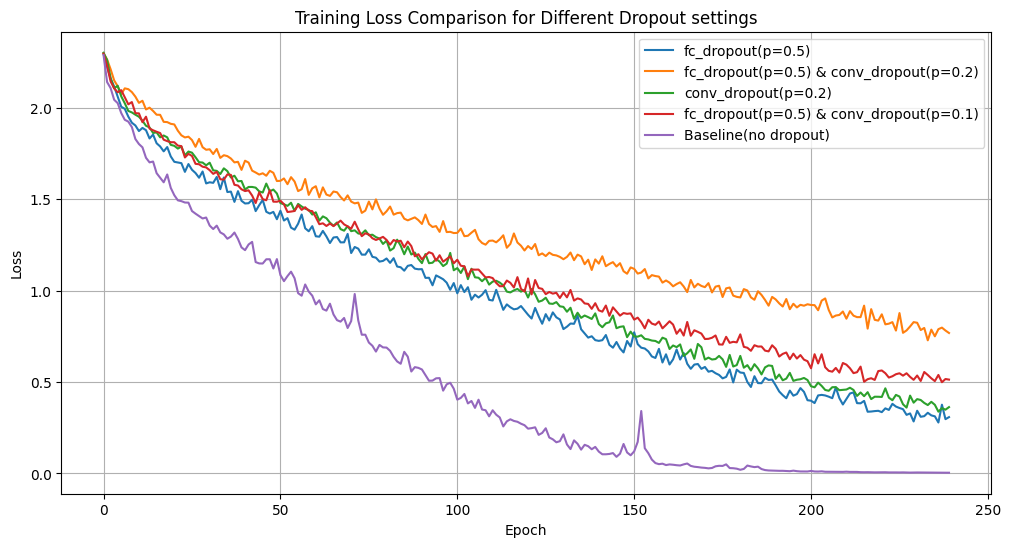

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][0][0], label=optimizer_name['name'])

plt.plot(baseline_train_losses, label='Baseline(no dropout)')

plt.title('Training Loss Comparison for Different Dropout settings')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

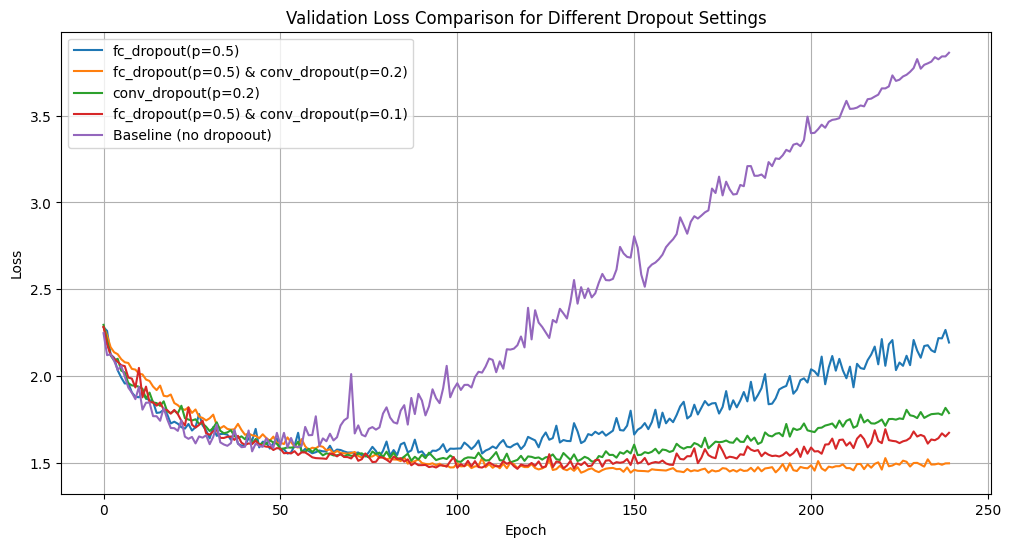

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(losses[optimizer_name['name']][1][0], label=optimizer_name['name'])

plt.plot(baseline_val_losses, label='Baseline (no dropoout)')

plt.title('Validation Loss Comparison for Different Dropout Settings')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

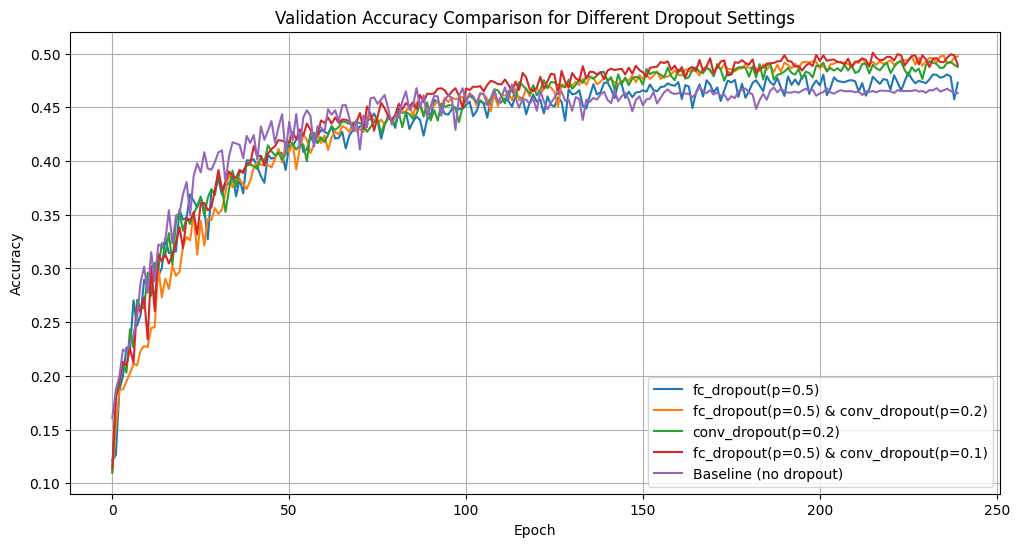

In [ ]:
plt.figure(figsize=(12, 6))
for optimizer_name in configs:
    plt.plot(accuracies[optimizer_name['name']][0], label=optimizer_name['name'])

plt.plot(baseline_val_accs, label='Baseline (no dropout)')

plt.title('Validation Accuracy Comparison for Different Dropout Settings')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

summary_data = {}

summary_data['Baseline (no dropout)'] = {
    'Final Train Loss': baseline_train_losses[-1],
    'Final Val Loss': baseline_val_losses[-1],
    'Final Val Accuracy': baseline_val_accs[-1]
}

for config in configs:
    summary_data[config['name']] = {
        'Final Train Loss': losses[config['name']][0][0][-1],
        'Final Val Loss': losses[config['name']][1][0][-1],
        'Final Val Accuracy': accuracies[config['name']][0][-1]
    }

summary_df = pd.DataFrame.from_dict(summary_data, orient='index')
display(summary_df)

,Final Train Loss,Final Val Loss,Final Val Accuracy
Baseline (no dropout),0.003991,3.862765,0.463163
fc_dropout(p=0.5),0.308169,2.193370,0.472735
fc_dropout(p=0.5) & conv_dropout(p=0.2),0.768600,1.497396,0.497449
conv_dropout(p=0.2),0.362916,1.786650,0.487490
fc_dropout(p=0.5) & conv_dropout(p=0.1),0.513526,1.673236,0.489388
